In [1]:
# Import necessary libraries
import os
import oggm
from oggm import cfg, workflow, tasks
from oggm.shop import millan22
import xarray as xr
import matplotlib.pyplot as plt



In [2]:
# Step 1: Initialize OGGM and configure paths
cfg.initialize()

# Set up the working directory
cfg.PATHS['working_dir'] = '/home/usman/Music/GeeMap/OGGM/data'

# Enable multiprocessing (optional for large datasets)
cfg.PARAMS['use_multiprocessing'] = True



2025-01-08 12:37:30: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-08 12:37:30: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-08 12:37:30: oggm.cfg: Multiprocessing: using all available processors (N=16)
2025-01-08 12:37:31: oggm.cfg: Multiprocessing switched ON after user settings.


In [5]:
# Step 2: Glacier Selection (Karambar Glacier RGI ID)
rgi_ids = ['RGI60-14.02192']  # Karambar Glacier

In [6]:
# The RGI version to use
# Size of the map around the glacier.
prepro_border = 10
# Degree of processing level. This is OGGM specific and for the shop 1 is the one you want
from_prepro_level = 3
# URL of the preprocessed gdirs
# we use elevation bands flowlines here
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5'
gdirs = workflow.init_glacier_directories(rgi_ids,
                                          from_prepro_level=from_prepro_level,
                                          prepro_base_url=base_url,
                                          prepro_border=prepro_border)

2025-01-08 12:40:05: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-01-08 12:40:05: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2025-01-08 12:40:05: oggm.utils: Downloading https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5/RGI62/b_010/L3/RGI60-14/RGI60-14.02.tar to /home/usman/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5/RGI62/b_010/L3/RGI60-14/RGI60-14.02.tar...


In [11]:
# Step 4: Add Millan et al. (2022) Ice Thickness Data
for gdir in gdirs:
    millan22.thickness_to_gdir(gdir)
    millan22.velocity_to_gdir(gdir)



2025-01-08 12:49:45: oggm.shop.millan22: (RGI60-14.02192) thickness_to_gdir
2025-01-08 12:49:46: oggm.shop.millan22: (RGI60-14.02192) velocity_to_gdir


In [13]:
  print(ds)

<xarray.Dataset> Size: 539kB
Dimensions:               (x: 178, y: 112)
Coordinates:
  * x                     (x) float32 712B -1.459e+04 -1.445e+04 ... 9.662e+03
  * y                     (y) float32 448B 4.06e+06 4.06e+06 ... 4.045e+06
Data variables:
    topo                  (y, x) float32 80kB 3.961e+03 3.945e+03 ... 4.164e+03
    topo_smoothed         (y, x) float32 80kB 3.948e+03 3.968e+03 ... 4.171e+03
    topo_valid_mask       (y, x) int8 20kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    glacier_mask          (y, x) int8 20kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    glacier_ext           (y, x) int8 20kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    millan_ice_thickness  (y, x) float32 80kB nan nan nan ... 305.0 328.2 327.4
    millan_v              (y, x) float32 80kB 0.0 0.0 0.0 ... 115.1 124.0 141.3
    millan_vx             (y, x) float32 80kB nan nan nan ... -48.67 -53.18
    millan_vy             (y, x) float32 80kB nan nan nan ... -114.0 -130.9
Attributes:
    author:       

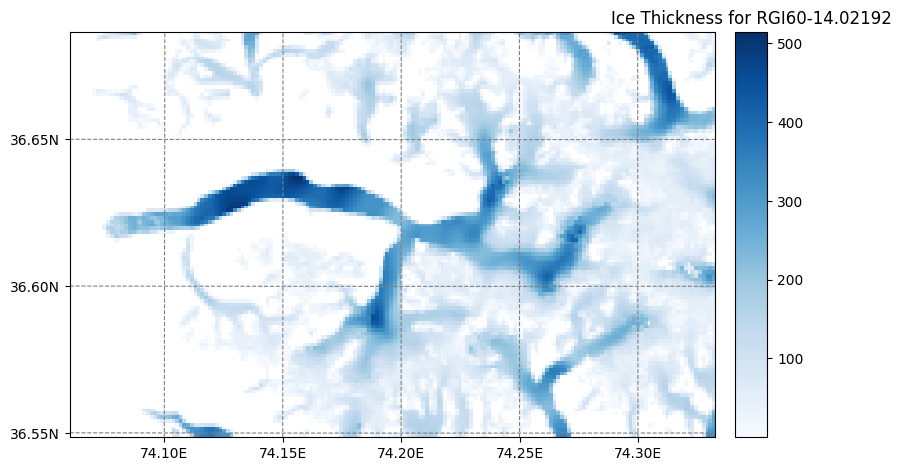

In [17]:
# Step 5: Plot Ice Thickness Data
for gdir in gdirs:
    with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
        ds = ds.load()
        # Visualize Ice Thickness
        f, ax = plt.subplots(figsize=(9, 9))
        smap = ds.salem.get_map(countries=False)
        smap.set_data(ds.millan_ice_thickness)
        smap.set_cmap('Blues')
        smap.visualize(ax=ax)
        plt.title(f"Ice Thickness for {gdir.rgi_id}")
        plt.show()
       


AttributeError: 'Dataset' object has no attribute 'consensus_velocity'

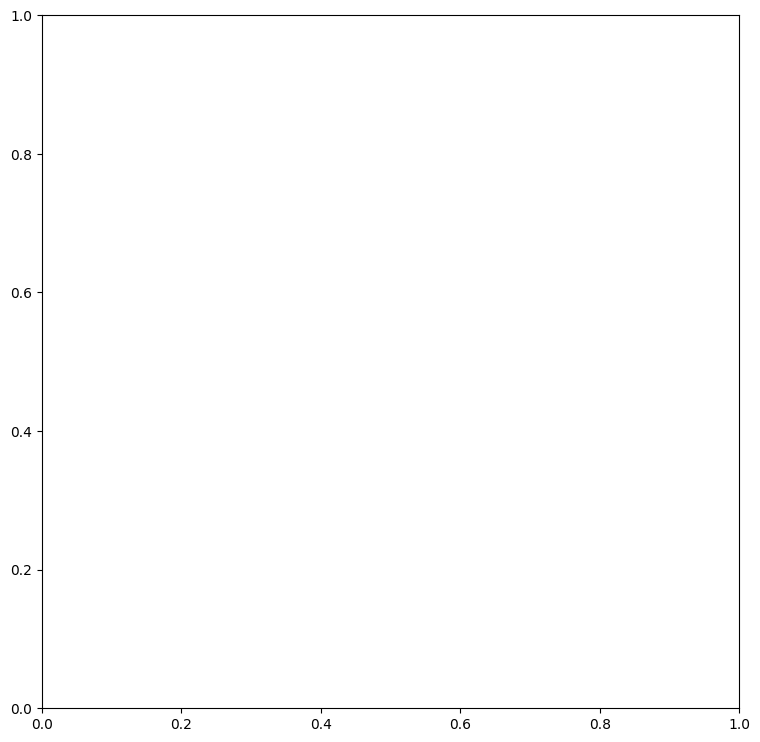

In [18]:
# Step 6: Plot Ice Velocity Data
for gdir in gdirs:
    with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
        ds = ds.load()
        
        # Visualize Ice Velocity
        f, ax = plt.subplots(figsize=(9, 9))
        smap = ds.salem.get_map(countries=False)
        smap.set_data(ds.consensus_velocity)
        smap.set_cmap('Reds')
        smap.visualize(ax=ax)
        plt.title(f"Ice Velocity for {gdir.rgi_id}")
        plt.show()




In [19]:
print(ds)

<xarray.Dataset> Size: 539kB
Dimensions:               (x: 178, y: 112)
Coordinates:
  * x                     (x) float32 712B -1.459e+04 -1.445e+04 ... 9.662e+03
  * y                     (y) float32 448B 4.06e+06 4.06e+06 ... 4.045e+06
Data variables:
    topo                  (y, x) float32 80kB 3.961e+03 3.945e+03 ... 4.164e+03
    topo_smoothed         (y, x) float32 80kB 3.948e+03 3.968e+03 ... 4.171e+03
    topo_valid_mask       (y, x) int8 20kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    glacier_mask          (y, x) int8 20kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    glacier_ext           (y, x) int8 20kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    millan_ice_thickness  (y, x) float32 80kB nan nan nan ... 305.0 328.2 327.4
    millan_v              (y, x) float32 80kB 0.0 0.0 0.0 ... 115.1 124.0 141.3
    millan_vx             (y, x) float32 80kB nan nan nan ... -48.67 -53.18
    millan_vy             (y, x) float32 80kB nan nan nan ... -114.0 -130.9
Attributes:
    author:       

In [ ]:
# Step 7: Compile Glacier Statistics (Optional)
stats = millan22.compile_millan_statistics(gdirs)
print(stats)

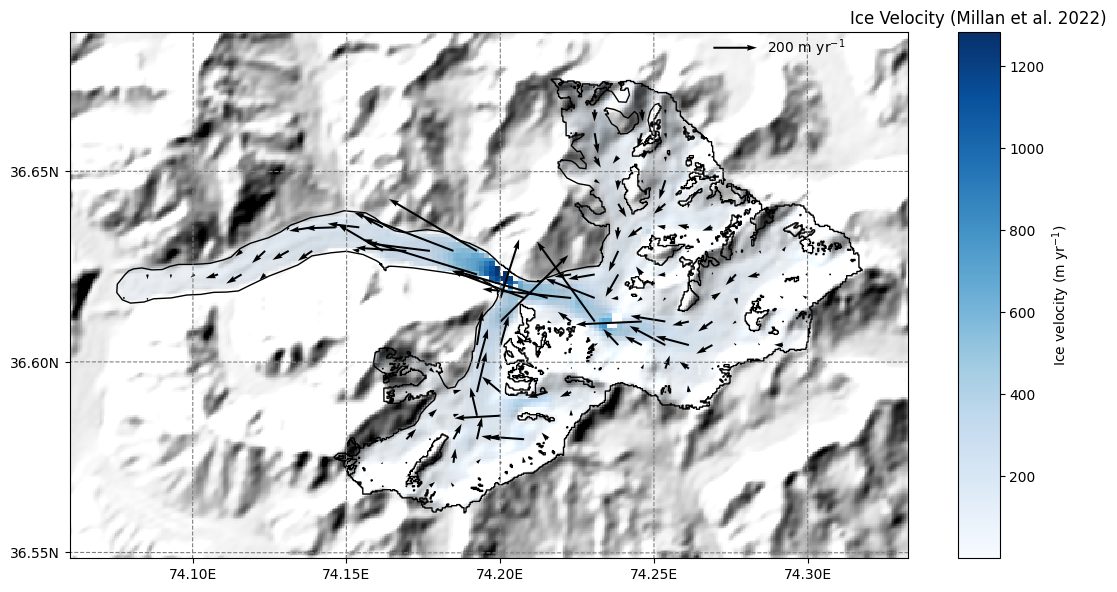

In [20]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Open the gridded dataset for the glacier directory
with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
    ds = ds.load()

# Plot the background topography and outline of the glacier
smap = ds.salem.get_map(countries=False)
smap.set_shapefile(gdir.read_shapefile('outlines'))
smap.set_topography(ds.topo.data)

# Extract velocity components
u = ds.millan_vx.where(ds.glacier_mask)  # x-component of velocity (masked to glacier area)
v = ds.millan_vy.where(ds.glacier_mask)  # y-component of velocity (masked to glacier area)

# Calculate magnitude of velocity
ws = (u**2 + v**2)**0.5  # Magnitude of ice velocity

# Prepare to plot
f, ax = plt.subplots(figsize=(12, 12))

# Quiver (arrows) only at every 5th grid point to reduce clutter
us = u[1::5, 1::5]
vs = v[1::5, 1::5]

# Set velocity magnitude data for plotting
smap.set_data(ws)
smap.set_cmap('Blues')

# Plot the map with ice velocity magnitude
smap.plot(ax=ax)
smap.append_colorbar(ax=ax, label='Ice velocity (m yr$^{-1}$)')

# Transform coordinates to the glacier map reference system
xx, yy = smap.grid.transform(us.x.values, us.y.values, crs=gdir.grid.proj)
xx, yy = np.meshgrid(xx, yy)

# Plot velocity vectors as arrows
qu = ax.quiver(xx, yy, us.values, vs.values)

# Add a legend (quiver key) for vector size
qk = ax.quiverkey(qu, 0.82, 0.97, 200, '200 m yr$^{-1}$',
                  labelpos='E', coordinates='axes')

plt.title('Ice Velocity (Millan et al. 2022)')
plt.show()
